## TD N°2 explicabilité du dataset Boston Housing

1) Charger le dataset bostong_housing
   1) Disponible dans le folder 04_interpretable_ml/td/data/
   
2) Nettoyer votre jeu de données pour créer une régression linéaire et un random forest
   1) Tester d'ajouter des features log, quadratique, ...

3)Créer un modèle baseline linéaire et random forest

4) Interpréter le modèle linéaire

5) Tuner votre random forest

6) Interpréter globalement votre modèle meilleur modèle RF 
   1) Utiliser les PDP ou ALE & Permutation feature Importance 
   2) Comparer les résulats du random forest avec votre interprétation du modèle linéaire

6) Réaliser une explicabilité par individu
   1) En utilisant la méthode ICE (PDP individuelle)
   2) LIME (Model local pour expliquer une prédiction)
   3) SHAP watterfall plot (Contribution marginale de chaque variable dans la prédiction)

7) Réaliser une explicabilité par individu sur le modèle RF
- 1) ICE, le PDP est-il une bonne représentation des variables importantes de votre modèle?
- 2) LIME
- 3) SHAP watterfall plot

8) Explorer les graphiques SHAP étudiés  dans la partie CM
   1) beeswarm (Contribution des variables)
   2) scatter (équivalent pdp)

## Contexte du Dataset

Le Boston Housing Dataset est un ensemble de données couramment utilisé en apprentissage automatique et en statistique pour étudier les relations entre diverses caractéristiques socio-économiques et immobilières dans la ville de Boston.  
Il contient des informations sur des propriétés résidentielles et leur environnement, et est souvent utilisé pour prédire la valeur des maisons, un problème classique de régression.

**Variable dispo**: 
- CRIM : taux de criminalité par habitant par ville
- ZN : proportion de terrains résidentiels zonés pour des lots de plus de 25 000 pieds carrés
- INDUS : proportion de terrains commerciaux non commerciaux par ville
- CHAS : variable binaire indiquant la proximité de la rivière Charles (= 1 si la zone délimitée par la ville touche la rivière ; 0 sinon)
- NOX : concentration des oxydes d'azote (en parties par 10 millions)
- RM : nombre moyen de pièces par logement
- AGE : proportion des unités occupées par leur propriétaire et construites avant 1940
- DIS : distances pondérées vers cinq centres d'emploi de Boston
- RAD : indice d'accessibilité aux autoroutes radiales
- TAX : taux d'imposition foncière par valeur totale pour chaque tranche de 10 000 dollars
- PTRATIO : ratio élèves-enseignants par ville
- LSTAT : pourcentage de la population de statut socio-économique inférieur
- MEDV : valeur médiane des maisons occupées par leur propriétaire (en milliers de dollars) - **variable cible**

In [132]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [133]:

import requests
import io
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
import alibi.explainers as ale
import lime
import lime.lime_tabular
import shap




### 1) Charger le dataset bostong_housing

In [134]:
#Télécharge directement depuis Github
url = "https://raw.githubusercontent.com/Roulitoo/cours_iae/master/04_INTERPRETABLE_ML/td/data/boston_housing.csv" 
download = requests.get(url).content

df = pd.read_csv(io.StringIO(download.decode('utf-8')), sep=';')

In [135]:
df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,5.33,36.2


### 2)Nettoyer votre jeu de données pour créer une régression linéaire et un random forest

Penser à :

- Vérifier comment encoder vos variables qualitatives pour la modélisation 
- Analyser les distributions
- Analyser les outliers 
- Analyser les corrélations

>Tester d'ajouter des features log, quadratique, ...

## EDA 

In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    int64  
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    int64  
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### Recherche des valeurs NA ou doublons 

In [137]:
df.isnull().sum() # Verifications des valeurs manquantes

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64

Pas de N/A presents dans notre data set 

In [138]:
df.duplicated().sum()# Verifications des valeurs en double 

0

In [139]:
df_complete_complete = df.drop(df.columns[0], axis=1) #On supprime la première colonne
df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,5.33,36.2


### Types des variables 

In [140]:
df = df.drop('Unnamed: 0', axis=1) # On suprime la premiere colonne 

Nous allons considerer les variabes RAD et CHAS comme qualitatives car CHAS est une variable binaire (0 ou 1) :

0 = le logement n'est pas à proximité de la rivière
1 = le logement est à proximité de la rivière


Et RAD est un indice catégoriel d’accessibilité aux autoroutes

In [141]:

# Variables qualitatives
df[['RAD', 'CHAS']] = df[['RAD', 'CHAS']].astype('category')

qualitatives_vars = ['RAD', 'CHAS']

# Variable quantitatives
quantitative_vars = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV']

### Statistiques descriptives

In [142]:
df[quantitative_vars].describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,37.970000,50.000000


L'analyse des statistiques descriptives nous permet d'observer que la variable ZN est fortement concentrée autour de 0. Les variables CRIM, LSTAT et DIS présentent une forte asymétrie, tandis que la variable AGE affiche une moyenne élevée et une large dispersion. De plus, les échelles des variables quantitatives sont très différentes les unes des autres.

### Correlations

In [143]:
corr = df[quantitative_vars].corr(method='pearson') # matrice de correlation methode pearson
corr.style.background_gradient(cmap='coolwarm')


C:\Users\isabe\AppData\Local\Temp\ipykernel_7668\2469704778.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df[quantitative_vars].corr(method='pearson') # matrice de correlation methode pearson


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,0.420972,-0.219247,0.352734,-0.379670,0.582764,0.289946,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.516604,0.311991,-0.569537,0.664408,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.763651,-0.391676,0.644779,-0.708027,0.720760,0.383248,0.603800,-0.483725
NOX,0.420972,-0.516604,0.763651,1.000000,-0.302188,0.731470,-0.769230,0.668023,0.188933,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,-0.302188,1.000000,-0.240265,0.205246,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.731470,-0.240265,1.000000,-0.747881,0.506456,0.261515,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.769230,0.205246,-0.747881,1.000000,-0.534432,-0.232471,-0.496996,0.249929
TAX,0.582764,-0.314563,0.720760,0.668023,-0.292048,0.506456,-0.534432,1.000000,0.460853,0.543993,-0.468536
PTRATIO,0.289946,-0.391679,0.383248,0.188933,-0.355501,0.261515,-0.232471,0.460853,1.000000,0.374044,-0.507787
LSTAT,0.455621,-0.412995,0.603800,0.590879,-0.613808,0.602339,-0.496996,0.543993,0.374044,1.000000,-0.737663


variables les plus corrélées avec MEDV

In [144]:
corr_target = df[quantitative_vars].corr()["MEDV"].sort_values(ascending=False)
print("Corrélation avec MEDV :\n", corr_target)

Corrélation avec MEDV :
 MEDV       1.000000
RM         0.695360
ZN         0.360445
DIS        0.249929
AGE       -0.376955
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64


C:\Users\isabe\AppData\Local\Temp\ipykernel_7668\180824432.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_target = df[quantitative_vars].corr()["MEDV"].sort_values(ascending=False)


La matrice de corrélation nous donne un aperçu des relations entre les variables. Nous nous concentrons ici sur les corrélations avec MEDV (le prix des maisons) et les fortes interdépendances entre variables. Nous pouvons observer que :

- RM	+0.695	➜ Plus le nombre de pièces est élevé, plus le prix des maisons est élevé

- LSTAT	-0.738	➜ Plus la population de faible statut socio-économique est élevée, plus les prix des maisons sont bas

- PTRATIO	-0.508	➜ Un taux élèves/enseignant élevé est associé à des prix de maisons plus bas

- INDUS	-0.484	➜ Quartiers plus industriels = prix plus bas

- TAX	-0.469	➜ Taxe foncière élevée = prix plus bas

- NOX	-0.427	➜ Pollution de l’air plus élevée = prix plus bas

- AGE	-0.377	➜ Vieilles constructions associées à des prix plus bas

- ZN	+0.360	➜ Quartiers résidentiels de grandes parcelles ont des prix plus élevés


Mais aussi nous observons que certaines variables sont fortement corrélées entre elles:

-INDUS & NOX	+0.764	Pollution plus élevée dans les zones industrielles 

- AGE & DIS	-0.748	Vieilles constructions souvent éloignées du centre-ville

- DIS & NOX	-0.769	Moins de pollution dans les zones éloignées des centres industriels

- TAX & INDUS	+0.721	Zones industrielles ont des taxes plus élevées

- LSTAT & RM	-0.614	Quartiers pauvres ont des logements plus petits


In [145]:
corr = df[quantitative_vars].corr(method='spearman') # matrice de correlation methode spearman
corr.style.background_gradient(cmap='coolwarm')

C:\Users\isabe\AppData\Local\Temp\ipykernel_7668\855044941.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df[quantitative_vars].corr(method='spearman') # matrice de correlation methode spearman


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,LSTAT,MEDV
CRIM,1.000000,-0.571660,0.735524,0.821465,-0.309116,0.704140,-0.744986,0.729045,0.465283,0.634760,-0.558891
ZN,-0.571660,1.000000,-0.642811,-0.634828,0.361074,-0.544423,0.614627,-0.371394,-0.448475,-0.490074,0.438179
INDUS,0.735524,-0.642811,1.000000,0.791189,-0.415301,0.679487,-0.757080,0.664361,0.433710,0.638747,-0.578255
NOX,0.821465,-0.634828,0.791189,1.000000,-0.310344,0.795153,-0.880015,0.649527,0.391309,0.636828,-0.562609
RM,-0.309116,0.361074,-0.415301,-0.310344,1.000000,-0.278082,0.263168,-0.271898,-0.312923,-0.640832,0.633576
AGE,0.704140,-0.544423,0.679487,0.795153,-0.278082,1.000000,-0.801610,0.526366,0.355384,0.657071,-0.547562
DIS,-0.744986,0.614627,-0.757080,-0.880015,0.263168,-0.801610,1.000000,-0.574336,-0.322041,-0.564262,0.445857
TAX,0.729045,-0.371394,0.664361,0.649527,-0.271898,0.526366,-0.574336,1.000000,0.453345,0.534423,-0.562411
PTRATIO,0.465283,-0.448475,0.433710,0.391309,-0.312923,0.355384,-0.322041,0.453345,1.000000,0.467259,-0.555905
LSTAT,0.634760,-0.490074,0.638747,0.636828,-0.640832,0.657071,-0.564262,0.534423,0.467259,1.000000,-0.852914


Le tableau des corrélations de Spearman montre des différences avec Pearson, ce qui nous indique que  certaines relations monotones mais non linéaires, par exemple on a LSTAT (-0.85) Corrélation plus forte que Pearson (-0.73), ce qui suggère une relation exponentielle. DIS (0.44) Différence notable avec Pearson (+0.25), relation non linéaire

## Outliers

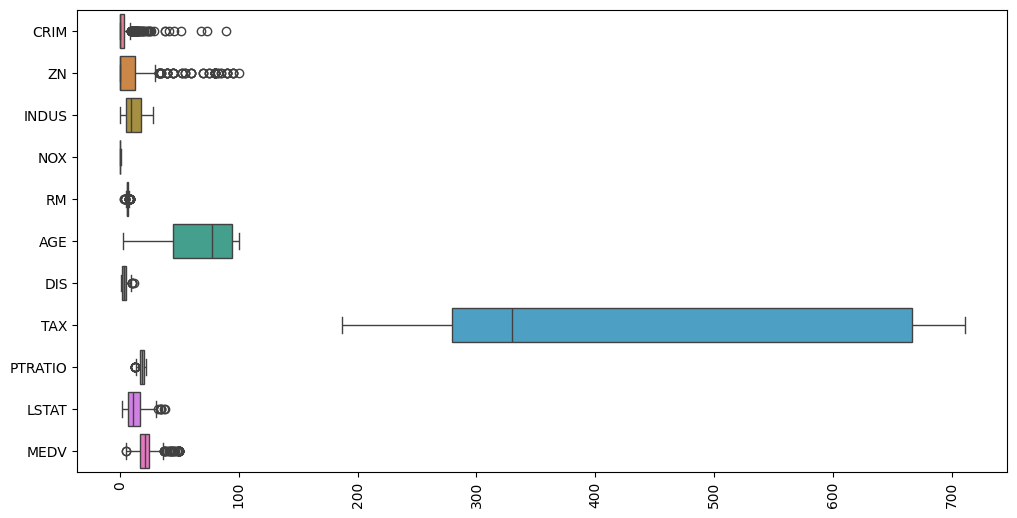

In [146]:
# Boîte à moustaches pour identifier les outliers
plt.figure(figsize=(12,6))
sns.boxplot(data=df, orient="h")
plt.xticks(rotation=90)
plt.show()

Nous pouvons observer la présence de plusieurs outliers dans nos variables, ainsi qu'une forte variation de la variable TAX


## Analyse des Distributions

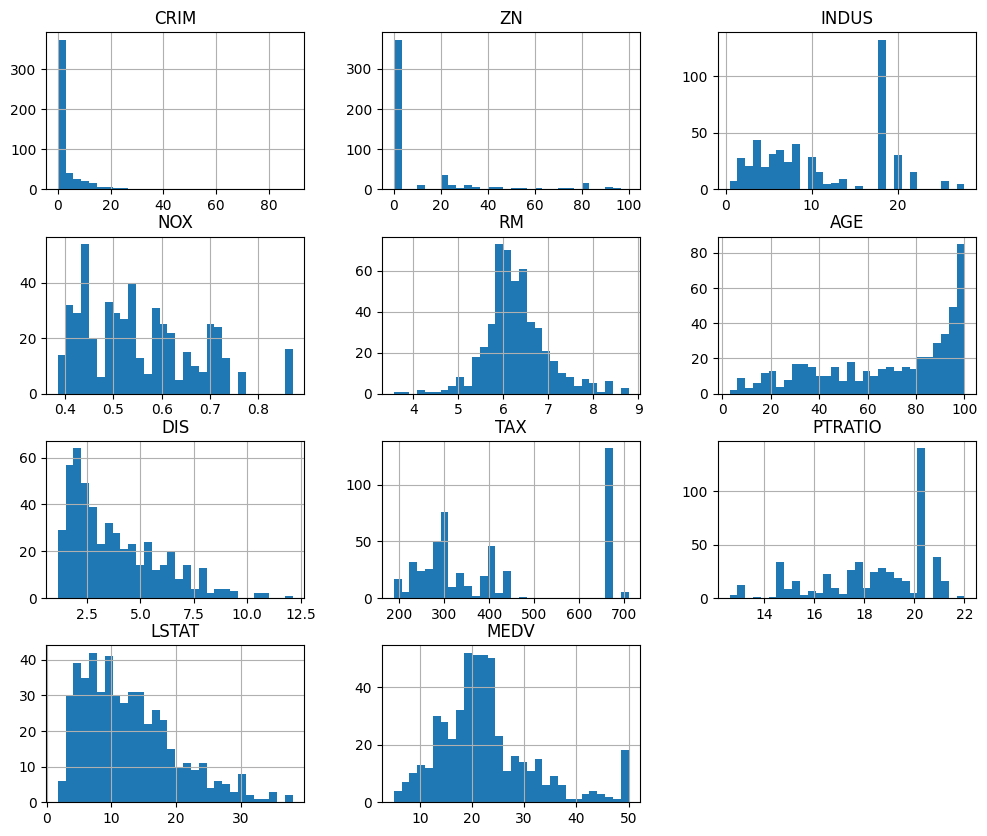

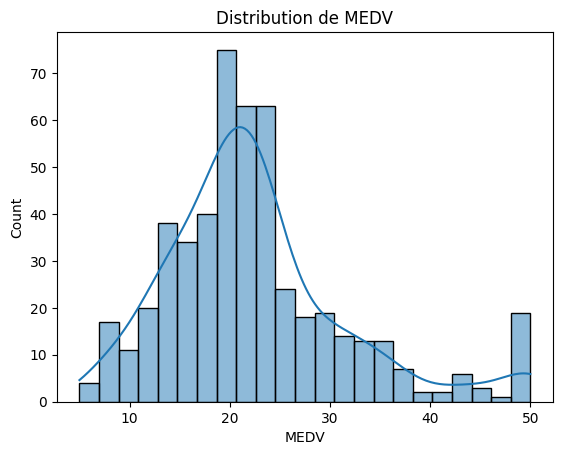

Skewness des variables :
 CRIM       5.223149
ZN         2.225666
MEDV       1.108098
DIS        1.011781
LSTAT      0.906460
NOX        0.729308
TAX        0.669956
RM         0.403612
INDUS      0.295022
AGE       -0.598963
PTRATIO   -0.802325
dtype: float64


C:\Users\isabe\AppData\Local\Temp\ipykernel_7668\992821321.py:11: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  skewness = df.skew().sort_values(ascending=False)


In [147]:
# histogrammes des variables numériques
df.hist(figsize=(12, 10), bins=30)
plt.show()

#  la distribution de la variable cible (MEDV)
sns.histplot(df["MEDV"], kde=True)
plt.title("Distribution de MEDV")
plt.show()

# la skewness (asymétrie)
skewness = df.skew().sort_values(ascending=False)
print("Skewness des variables :\n", skewness)


D'après le graphique de distribution et la skewness, qui mesure l'asymétrie, nous constatons que la variable CRIM (5.22) est très asymétrique (longue queue à droite), suivie par les variables ZN (2.22), DIS (1.01) et LSTAT (0.91). Il serait intéressant d'appliquer une transformation logarithmique pour atténuer cette asymétrie.
Les autres variables, bien qu'elles présentent également une certaine asymétrie, restent dans des limites modérées et ne nécessitent pas forcément de correction.

### Analyse Bivarie avec la target 

c:\Users\isabel\M2_ECAP\semestre_1\SVM_reseaux_neurones\env_SVM_reseaux_n\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


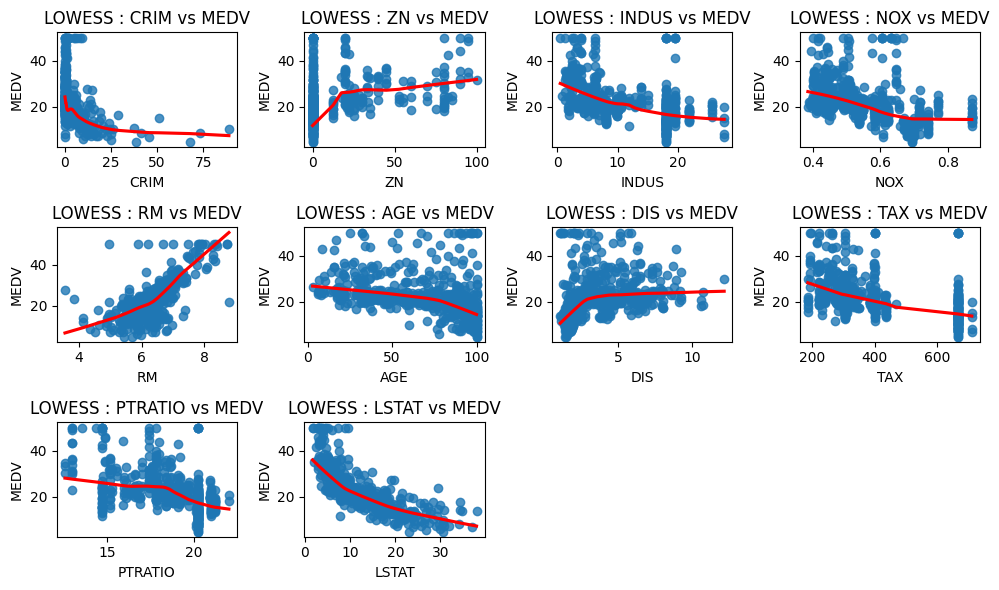

In [148]:
# Scatter plot pour voir la relation avec MEDV
plt.figure(figsize=(10, 6))
for i, col in enumerate(["CRIM", "ZN", "INDUS", "NOX", "RM", "AGE", "DIS", "TAX", "PTRATIO", "LSTAT"]):
    plt.subplot(3, 4, i+1)
    sns.regplot(x=df[col], y=df["MEDV"], lowess=True, line_kws={"color": "red"})  # LOWESS = Local Weighted Regression
    plt.title(f"LOWESS : {col} vs MEDV")
plt.tight_layout()
plt.show()

D'après les courbes LOWESS sur les scatter plots, nous pouvons identifier les relations non linéaires entre les variables explicatives et la cible MEDV. Une relation non linéaire signifie que l'effet d'une variable sur MEDV n'est pas constant et pourrait être mieux modélisé avec une transformation quadratique ou d'autres transformations non linéaires

 ### Variables de types qualitative
 
 Graphique en barres pour CHAS

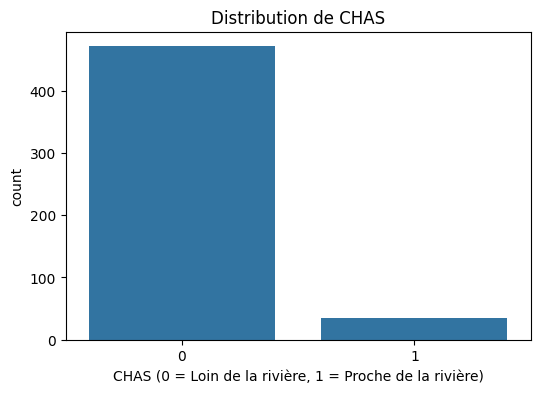

In [149]:

plt.figure(figsize=(6, 4))
sns.countplot(x=df["CHAS"])
plt.title("Distribution de CHAS")
plt.xlabel("CHAS (0 = Loin de la rivière, 1 = Proche de la rivière)")
plt.show()


La variable CHAS est fortement déséquilibrée, on observe que très peu de logements (1) sont proches de la rivière, tandis que la majorité (0) en sont éloignés

 Graphique en barres pour RAD

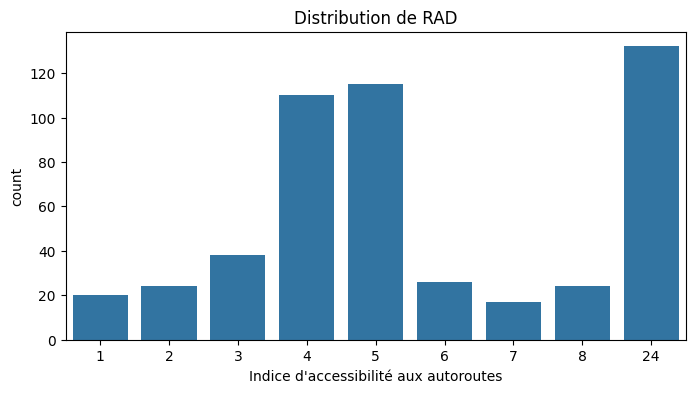

In [150]:
plt.figure(figsize=(8, 4))
sns.countplot(x=df["RAD"])
plt.title("Distribution de RAD")
plt.xlabel("Indice d'accessibilité aux autoroutes")
plt.show()


Certaines valeurs (comme 4, 5, 24) sont beaucoup plus fréquentes que d'autres

### Impact de CHAS et RAD sur MEDV

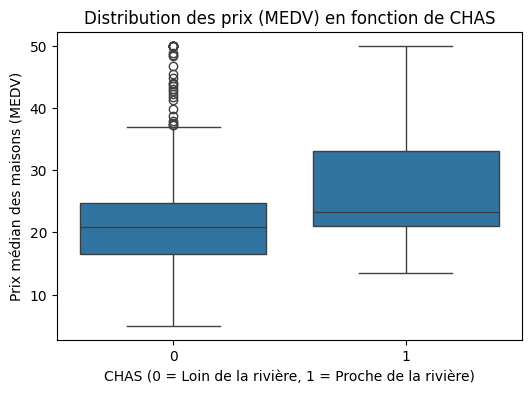

In [151]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["CHAS"], y=df['MEDV'])
plt.title("Distribution des prix (MEDV) en fonction de CHAS")
plt.xlabel("CHAS (0 = Loin de la rivière, 1 = Proche de la rivière)")
plt.ylabel("Prix médian des maisons (MEDV)")
plt.show()

Les maisons proches de la rivière (CHAS = 1) ont un prix médian (MEDV) plus élevé que celles qui sont loin (CHAS = 0). La distribution des prix pour CHAS = 1 est plus étendue avec des prix plus élevés, tandis que pour CHAS = 0, on observe plus d’outliers vers le haut

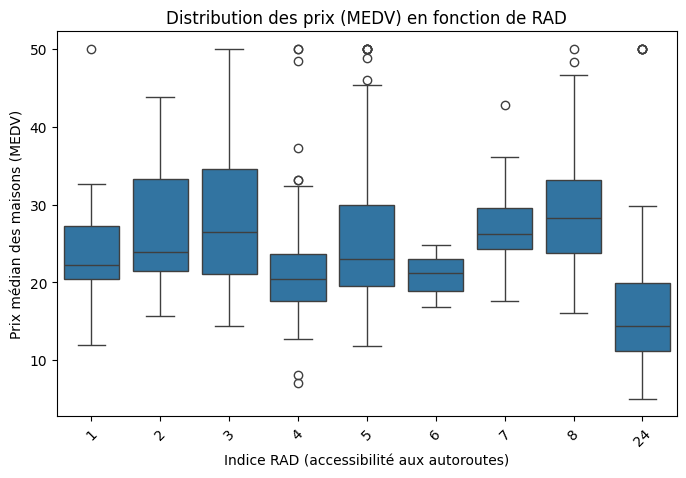

In [152]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df["RAD"], y=df['MEDV'])
plt.title("Distribution des prix (MEDV) en fonction de RAD")
plt.xlabel("Indice RAD (accessibilité aux autoroutes)")
plt.ylabel("Prix médian des maisons (MEDV)")
plt.xticks(rotation=45)
plt.show()


Les prix sont très dispersés selon les valeurs de RAD, ce qui suggère que RAD ne suit pas un effet ordonné sur MEDV

# Traitement 

Nous allons d'abord  diviser les données en train et test, car lorsqu’on construit un modèle de machine learning, on veut qu’il fonctionne bien sur des données nouvelles, et pas seulement sur celles utilisées pour l’entraîner. Pour s’assurer qu’il est capable de généraliser, on garde une partie des données de côté (test) et on entraîne le modèle uniquement sur l’autre partie (train).

Si on applique des transformations sur l’ensemble du dataset avant de séparer, on risque d’introduire dans l’entraînement des informations qui devraient rester inconnues du modèle. En divisant d’abord, on s’assure que toutes les transformations (comme le traitement des valeurs extrêmes, la normalisation, ou la création de nouvelles variables) sont basées uniquement sur les données d’entraînement, et on applique ensuite les mêmes règles au test. Cela permet d’évaluer correctement la performance du modèle sur des données qu’il n’a jamais vues

In [153]:
# Séparation de la cible et les features
X = df.drop(columns=["MEDV"])  
y = df["MEDV"]

# Séparation en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Veleurs aberrants  

Nous allons utiliser la fonctio de  winsorisation (vu en cours), qui permet de réduit l’impact des valeurs extrêmes en les remplaçant par des seuils définis

In [154]:
# fonction permettant de traiter les valeurs aberrants dans le jeu de donnees 
def winsorize_data(xtrain, xtest, feature):

    """_summary_

    Fonction permettant de winsorizez un jeu d'entrainement et de test en calculant
    les quantiles sur le jeu d'entrainement et l'appliquant sur le jeu test.

    Pour se prémunir d'un data leak.
    
    """
    
    # Définir les quantiles sur xtrain
    lower_quantile = 0.05  # 5% quantile
    upper_quantile = 0.95  # 95% quantile

    # Calcul des bornes à partir des quantiles sur xtrain
    lower_bound = np.quantile(xtrain[feature], lower_quantile)
    upper_bound = np.quantile(xtrain[feature], upper_quantile)

    # Appliquer la winsorisation sur xtrain
    xtrain_winsorized = np.clip(xtrain[feature], lower_bound, upper_bound)

    # Appliquer les mêmes bornes sur xtest
    xtest_winsorized = np.clip(xtest[feature], lower_bound, upper_bound)

    return(xtrain_winsorized, xtest_winsorized)

In [155]:
#Winsorize outliers
for col in X_train.columns:
    print(f" winsorization de la variable : {col}") 
    X_train[col], X_test[col] = winsorize_data(xtrain= X_train, xtest= X_test, feature=col)

 winsorization de la variable : CRIM
 winsorization de la variable : ZN
 winsorization de la variable : INDUS
 winsorization de la variable : CHAS
 winsorization de la variable : NOX
 winsorization de la variable : RM
 winsorization de la variable : AGE
 winsorization de la variable : DIS
 winsorization de la variable : RAD
 winsorization de la variable : TAX
 winsorization de la variable : PTRATIO
 winsorization de la variable : LSTAT


### Features Logarithmiques et Quadratiques

Nous commencons par transformer les variables presentant une forte asymetrie en log afin de La transformation logarithmique est particulièrement utile pour réduire l’asymétrie et rendre la distribution plus normale, ce qui facilite la modélisation

In [156]:
features_log = ["CRIM", "ZN", "DIS", "LSTAT"]
for feature in features_log:
    X_train[feature + "_log"] = np.log1p(X_train[feature])
    X_test[feature + "_log"] = np.log1p(X_test[feature])

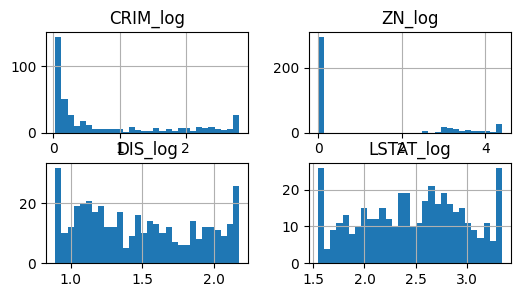

In [157]:
X_train[["CRIM_log", "ZN_log", "DIS_log", "LSTAT_log"]].hist(figsize=(6, 3), bins=30)
plt.show()

In [158]:
""""

poly = PolynomialFeatures(degree=2, include_bias=False)

# Fit sur X_train
X_train_poly = poly.fit_transform(X_train[["RM", "LSTAT", "DIS"]])
X_test_poly = poly.transform(X_test[["RM", "LSTAT", "DIS"]])  # Transformer sans refit

# Convertir en DataFrame avec noms uniques
df_train_poly = pd.DataFrame(X_train_poly, columns=[f"{col}_poly" for col in poly.get_feature_names_out(["RM", "LSTAT", "DIS"])])
df_test_poly = pd.DataFrame(X_test_poly, columns=[f"{col}_poly" for col in poly.get_feature_names_out(["RM", "LSTAT", "DIS"])])

# Ajouter les nouvelles variables polynomiales aux datasets
X_train = X_train.join(df_train_poly)
X_test = X_test.join(df_test_poly)

#  Supprimer les variables brutes si elles ne sont plus nécessaires
# X_train.drop(columns=["RM", "LSTAT", "DIS"], inplace=True, errors="ignore")
# X_test.drop(columns=["RM", "LSTAT", "DIS"], inplace=True, errors="ignore")

"""


'"\n\npoly = PolynomialFeatures(degree=2, include_bias=False)\n\n# Fit sur X_train\nX_train_poly = poly.fit_transform(X_train[["RM", "LSTAT", "DIS"]])\nX_test_poly = poly.transform(X_test[["RM", "LSTAT", "DIS"]])  # Transformer sans refit\n\n# Convertir en DataFrame avec noms uniques\ndf_train_poly = pd.DataFrame(X_train_poly, columns=[f"{col}_poly" for col in poly.get_feature_names_out(["RM", "LSTAT", "DIS"])])\ndf_test_poly = pd.DataFrame(X_test_poly, columns=[f"{col}_poly" for col in poly.get_feature_names_out(["RM", "LSTAT", "DIS"])])\n\n# Ajouter les nouvelles variables polynomiales aux datasets\nX_train = X_train.join(df_train_poly)\nX_test = X_test.join(df_test_poly)\n\n#  Supprimer les variables brutes si elles ne sont plus nécessaires\n# X_train.drop(columns=["RM", "LSTAT", "DIS"], inplace=True, errors="ignore")\n# X_test.drop(columns=["RM", "LSTAT", "DIS"], inplace=True, errors="ignore")\n\n'

In [159]:
X_train.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,CRIM_log,ZN_log,DIS_log,LSTAT_log
477,15.02340,0.0,18.10,0.0,0.6140,5.35515,97.3,2.1007,24.0,666.0,20.2,24.91,2.774050,0.000000,1.131628,3.254629
15,0.62739,0.0,8.14,0.0,0.5380,5.83400,56.5,4.4986,4.0,307.0,21.0,8.47,0.486978,0.000000,1.704494,2.248129
332,0.03466,35.0,6.06,0.0,0.4379,6.03100,23.3,6.6407,2.0,304.0,16.9,7.83,0.034073,3.583519,2.033489,2.178155
423,7.05042,0.0,18.10,0.0,0.6140,6.10300,85.1,2.0218,24.0,666.0,20.2,23.29,2.085724,0.000000,1.105853,3.190065
19,0.72580,0.0,8.14,0.0,0.5380,5.72700,69.5,3.7965,4.0,307.0,21.0,11.28,0.545691,0.000000,1.567886,2.507972


In [160]:
X_test.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,CRIM_log,ZN_log,DIS_log,LSTAT_log
173,0.09178,0.0,4.05,0.0,0.510,6.416,84.10,2.6463,5.0,296.0,16.6,9.0400,0.087809,0.000000,1.293713,2.306577
274,0.05644,40.0,6.41,1.0,0.447,6.758,32.90,4.0776,4.0,254.0,17.6,3.7045,0.054905,3.713572,1.624839,1.548519
491,0.10574,0.0,19.58,0.0,0.609,5.983,98.80,1.8681,4.0,666.0,20.1,18.0700,0.100515,0.000000,1.053650,2.948116
72,0.09164,0.0,10.81,0.0,0.413,6.065,17.53,5.2873,4.0,305.0,19.2,5.5200,0.087681,0.000000,1.838532,1.874874
452,5.09017,0.0,18.10,0.0,0.713,6.297,91.80,2.3682,24.0,666.0,20.2,17.2700,1.806676,0.000000,1.214378,2.905260


### Standardisation  et encodage 

In [161]:
quantitative_vars = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT'] # on n'inclut plus la variable MEDV 
qualitatives_vars = ['RAD'] # on n'inclut plus la variable CHAS, on la garde en garder tel quel (0 ou 1) 

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), quantitative_vars),  # Standardisation des variables numériques
    ("cat", OneHotEncoder(drop="first"), qualitatives_vars)  # Encodage One-Hot des variables qualitatives
])


# sur les données train et test
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


num_feature_names = quantitative_vars
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(qualitatives_vars).tolist()
feature_names = num_feature_names + cat_feature_names

X_train_s = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)
X_test_s = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

X_train_s["CHAS"] = X_train["CHAS"].values  # Ajouter la colonne originale non modifiée
X_test_s["CHAS"] = X_test["CHAS"].values

In [162]:
X_train_s.head() # verification 

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,RAD_3.0,RAD_4.0,RAD_5.0,RAD_6.0,RAD_7.0,RAD_8.0,RAD_24.0,CHAS
477,2.673737,-0.507898,1.126552,0.562785,-1.617486,1.040397,-0.835044,1.709704,1.593002,0.877941,1.900523,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
15,-0.461172,-0.507898,-0.410779,-0.138908,-0.812348,-0.452713,0.371915,-0.632118,-0.597993,1.262739,-0.582035,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
332,-0.590246,1.063928,-0.731828,-1.063111,-0.481113,-1.667695,1.450119,-0.866300,-0.616302,-0.709353,-0.678679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
423,0.937522,-0.507898,1.126552,0.562785,-0.360052,0.593928,-0.874758,1.709704,1.593002,0.877941,1.655891,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19,-0.439742,-0.507898,-0.410779,-0.138908,-0.992258,0.023033,0.018520,-0.632118,-0.597993,1.262739,-0.157705,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3)Créer 2 modèles baseline, linéaire et random forest

Regression lineaire

In [163]:
# Initialisation et entraînement du modèle
lr_model = LinearRegression()
lr_model.fit(X_train_s, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test_s)

# Évaluation du modèle
mse_lr = mean_squared_error(y_test, y_pred_lr)  
rmse_lr = np.sqrt(mse_lr)# RMSE
r2_lr = r2_score(y_test, y_pred_lr)  # R²

print(f"Régression Linéaire - RMSE : {rmse_lr:.3f}, R² : {r2_lr:.3f}")

Régression Linéaire - RMSE : 4.480, R² : 0.726


random forest

In [164]:
# Initialisation et entraînement du modèle
rf_model = RandomForestRegressor( random_state=42)
rf_model.fit(X_train_s, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test_s)

# Évaluation du modèle
mse_rf = mean_squared_error(y_test, y_pred_rf) 
rmse_rf = np.sqrt(mse_rf)# RMSE
r2_rf = r2_score(y_test, y_pred_rf)  # R²

print(f"Random Forest - RMSE : {rmse_rf:.3f}, R² : {r2_rf:.3f}")

Random Forest - RMSE : 3.053, R² : 0.873


### 4) Interpréter le modèle linéaire
Utiliser les méthodes intrinsèques du modèle pour l'interprétation.

Nous allons donc recuperer les  coefficients dans la regression lineaire, ce qui permet de voir quelles sont les variables les plus influentes


In [165]:
pd.DataFrame({
    "Variable": X_train_s.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", ascending=False)

,Variable,Coefficient
11,RAD_3.0,3.613579
4,RM,3.161318
18,CHAS,2.660642
7,RAD,2.583689
15,RAD_7.0,2.147019
16,RAD_8.0,1.614621
13,RAD_5.0,0.991358
12,RAD_4.0,0.842985
1,ZN,0.675577
2,INDUS,0.096353


La variable LSTAT, qui mesure le pourcentage de population à faible revenu, a une forte relation négative avec MEDV (-3.82), indiquant que plus ce taux est élevé, plus le prix des maisons diminue. De même, la distance aux centres d’emploi (DIS, -3.56) et la pollution (NOX, -2.21) influencent négativement les prix, soulignant l’importance de la proximité des pôles économiques et de la qualité de l’environnement.

À l’inverse, le nombre moyen de pièces (RM, 3.16) et l’accessibilité aux autoroutes (RAD_3.0, 3.61 ; RAD_7.0, 2.14, etc.) sont des facteurs déterminants qui augmentent la valeur des maisons, ce qui suggère que les acheteurs privilégient les logements spacieux et bien desservis. De plus, la proximité de la rivière (CHAS, 2.66) a un effet positif significatif sur le prix des maisons. Toutefois, certaines autoroutes, comme RAD_24.0 (-0.11), ont un impact légèrement négatif, probablement en raison de nuisances.

Enfin, des facteurs comme la criminalité (CRIM, -1.70), un taux d’imposition élevé (TAX, -1.12) et un ratio élèves/professeurs élevé (PTRATIO, -1.84) sont également associés à une baisse des prix, reflétant les préférences des acheteurs pour des environnements sûrs, fiscalement avantageux et avec une bonne qualité éducative.

En complément de ces coefficients, le modèle a un RMSE de 4.480, ce qui signifie que l’erreur moyenne des prédictions est d’environ 4 480$ sur le prix médian des maisons. Le R² de 0.726 indique que 72,6 % de la variance des prix des maisons est expliquée par le modèle, ce qui signifie qu'il capture bien les tendances générales, mais qu’il reste une marge d’erreur non expliquée.

### 5) Tuner votre random forest

Nous allons optimiser notre modele random forest avec un Gridsearch

In [166]:
param_grid = {
    "n_estimators": [100, 200, 300],   # Nombre d’arbres
    "max_depth": [10, 20, None],       # Profondeur maximale
    "min_samples_split": [2, 5, 10],   # Nombre min d’échantillons pour un split
    "min_samples_leaf": [1, 2, 4],     # Nombre min d’échantillons dans une feuille
    "max_features": ["sqrt", "log2"],  # Nombre de features considérées
    "bootstrap": [True, False]         # Échantillonnage avec ou sans remplacement
}

# GridSearch avec validation croisée 5-fold
grid_search = GridSearchCV(
    rf_model, param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2
)

# Entraînement du modèle optimisé
grid_search.fit(X_train_s, y_train)

# Meilleurs hyperparamètres
print("Meilleurs paramètres :", grid_search.best_params_)

# Meilleure performance RMSE
print("Meilleur RMSE :", -grid_search.best_score_) # on prend l'oppose du score

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Meilleurs paramètres : {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Meilleur RMSE : 3.5988360870032254


Le gridSearchCV divise X_train en plusieurs sous-ensembles (folds) et entraîne le modèle sur un sous-ensemble tout en le validant sur un autre, la valeur best_score_ correspond donc au meilleur RMSE obtenu pendant la validation croisée. Pour mesurer la vraie performance sur des données non vues, il faut réentraîner Random Forest avec les meilleurs hyperparamètres et le tester sur X_test

### Test du modèle optimisé sur le jeu de test

In [167]:

# Réentraînement  avec les meilleurs hyperparamètres
rf_optimized = RandomForestRegressor(
    **grid_search.best_params_, random_state=42
)

rf_optimized.fit(X_train_s, y_train)  

# Prédictions sur le jeu de test
y_pred_rf_opt = rf_optimized.predict(X_test_s)

# Évaluation du modèle optimisé sur X_test
rmse_rf_opt = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt))  # RMSE
r2_rf_opt = r2_score(y_test, y_pred_rf_opt)  # R²

print(f"Random Forest Optimisé - RMSE sur test : {rmse_rf_opt:.3f}, R² : {r2_rf_opt:.3f}")


Random Forest Optimisé - RMSE sur test : 3.315, R² : 0.850


Bien que les prédictions du modèle optimisé soient légèrement moins précises que celles du modèle baseline, avec un RMSE passant de 3.053 à 3.315 et un R² de 0.873 à 0.850, la différence de performance indique que l’optimisation n’a pas nécessairement amélioré le modèle. Cela suggère que le modèle de base était déjà bien paramétré, et que l’optimisation avec GridSearch n’a pas apporté de gains significatifs, voire a légèrement réduit la capacité du modèle à généraliser

Le modèle baseline avait peut-être déjà une bonne configuration, et l’optimisation n’a pas forcément trouvé de meilleurs hyperparamètres, pour la suite nous continuerons avec ce modele 

### 6) Interpréter globalement votre modèle meilleur modèle RF 
   1) Utiliser les PDP ou ALE & Permutation feature Importance 
   2) Comparer les résulats du random forest avec votre interprétation du modèle linéaire

### PDP (Partial Dependence Plot)
Le PDP (Graphique de dépendance partielle) montre comment une variable influence la prédiction en moyenne, en maintenant les autres constantes.

on veut voir comment le modèle généralise sur de nouvelles données, donc on utilisera X_test

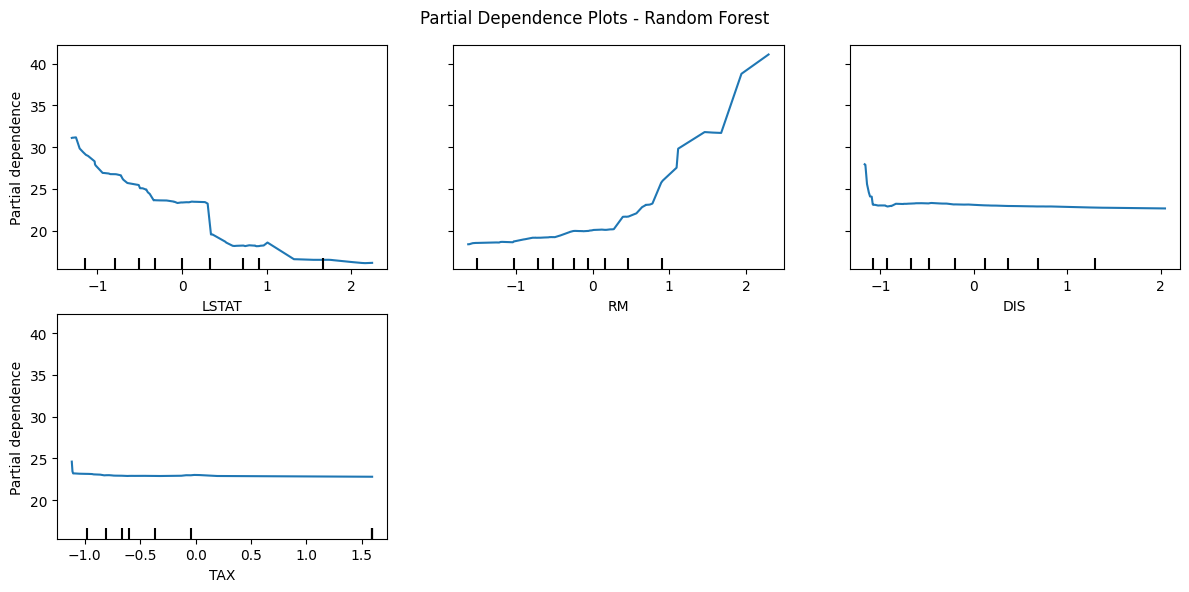

In [168]:
# PDP pour Random Forest
features = ["LSTAT", "RM", "DIS", "TAX"]

fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(rf_model,
                                        X_test_s, 
                                        features,
                                        kind="average", # Pour obtenir une PDP
                                        grid_resolution=100, #Nombre de points estimés pour le tracer de la courbe
                                        ax = ax)
plt.suptitle("Partial Dependence Plots - Random Forest")
plt.tight_layout()
plt.show()

D'après le Partial Dependence Plot (PDP), on observe que pour la variable LSTAT (pourcentage de population à faible revenu), la courbe diminue fortement, ce qui signifie que plus LSTAT est élevé, plus la prédiction du prix de la maison diminue. Cela confirme une relation négative forte entre la pauvreté et la valeur des biens immobiliers.

À l'inverse, la variable RM (nombre de pièces) montre une courbe croissante, indiquant que plus une maison a de pièces, plus son prix médian augmente. L'effet semble non linéaire, avec une accélération de la hausse pour les valeurs élevées de RM, suggérant que les maisons plus grandes sont particulièrement prisées.

En ce qui concerne la variable DIS (distance aux centres d'emploi), la courbe est presque plate, ce qui signifie que cette variable a un impact limité sur la prédiction des prix. Cela peut indiquer que l’effet de DIS est absorbé par d’autres variables corrélées, comme LSTAT ou TAX.

Enfin, la variable TAX (taux d’imposition foncière) n’a qu’un effet très faible sur MEDV, sa courbe restant quasi horizontale. Cela suggère que les taxes locales influencent peu la valeur médiane des logements dans ce modèle.

Comme les variables avaient été standardisées, on observe des valeurs comprises entre -1 et 2 sur l’axe des abscisses, ce qui correspond aux écarts-types des variables après transformation

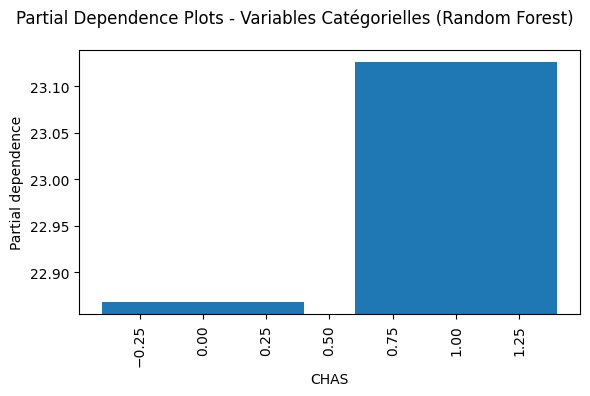

In [169]:

# variables catégorielles à analyser
categorical_features = ["CHAS"] 

# Création du PDP pour les variables catégorielles
fig, ax = plt.subplots(figsize=(6, 4))

pdp_display = PartialDependenceDisplay.from_estimator(
    rf_model, 
    X_test_s,  
    categorical_features, 
    categorical_features=categorical_features,  # Spécification des variables catégorielles
    kind="average", 
    ax=ax)

plt.suptitle("Partial Dependence Plots - Variables Catégorielles (Random Forest)")
plt.tight_layout()
plt.show()


Lorsque CHAS = 0 (loin de la rivière), la prédiction moyenne de MEDV est plus basse (~22.75)

Lorsque CHAS = 1 (proche de la rivière), la prédiction moyenne de MEDV est plus élevée (~24.25)

L'écart entre les deux barres montre que la proximité de la rivière a un effet positif sur le prix des maisons.

### ALE & Permutation feature Importance 

Effet marginal d'une variable par interval sur la target, car contrairement aux PDP, ALE corrige l’effet des corrélations entre variables, ce qui donne une estimation plus réaliste de l’impact de chaque variable

c:\Users\isabel\M2_ECAP\semestre_1\SVM_reseaux_neurones\env_SVM_reseaux_n\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\isabel\M2_ECAP\semestre_1\SVM_reseaux_neurones\env_SVM_reseaux_n\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\isabel\M2_ECAP\semestre_1\SVM_reseaux_neurones\env_SVM_reseaux_n\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\isabel\M2_ECAP\semestre_1\SVM_reseaux_neurones\env_SVM_reseaux_n\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\U

array([[<Axes: xlabel='LSTAT', ylabel='ALE'>,
        <Axes: xlabel='RM', ylabel='ALE'>,
        <Axes: xlabel='DIS', ylabel='ALE'>],
       [<Axes: xlabel='TAX', ylabel='ALE'>, None, None]], dtype=object)

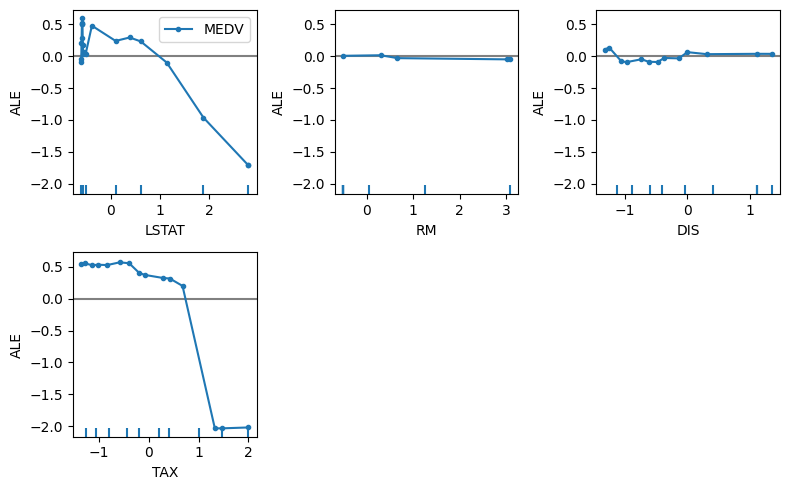

In [170]:
features = ["LSTAT", "RM", "DIS", "TAX"]


rf_ale = ALE(rf_model.predict, #Methode predict de votre modèle

             feature_names=features, # Liste des features où il faut calculer l'ALE

             target_names=["MEDV"] # Nom de la target

) 

#Calcul des ALE, attention il faut un format numpy arrray

rf_exp = rf_ale.explain(X_test_s.to_numpy()) 


#Plot pour l'interprétation


_, ax1 = plt.subplots(figsize = (8,5))

plot_ale(rf_exp, #Résultats des ALE

     features=features, # Feature à représenter

     ax= ax1 # Si classification mutliple, passer le nom de toutes les modalités à prédire

)


Lorsque LSTAT augmente, on voit un effet fortement negatif de  la valeur médiane des maisons qui chute drastiquement. On peut donc interpreter en disant que plus la proportion de population à bas revenu est élevée, plus les prix des maisons sont faibles.

L’augmentation de RM semble légèrement augmenter MEDV, mais beaucoup moins qu'attendu. Et pour la variable DIS la courbe est presque plate et elle n’a pas un fort impact direct sur MEDV. 

Le taux d'imposition, montre un effet faible jusqu'à une certaine valeur, puis baisse brutale. Une taxation modérée n’a pas d’impact majeur sur le prix des maisons, mais au-delà d’un certain seuil, elle devient un facteur négatif majeur

### Comparaison des resultats avec PDP et ALE

- LSTAT (pourcentage de population pauvre):

PDP : Montre une forte décroissance, indiquant que plus LSTAT est élevé, plus MEDV diminue

ALE : Confirme cet effet, mais avec une pente plus prononcée, suggérant que l’effet négatif est encore plus marqué après correction des corrélations

- RM (nombre de pièces)

 PDP : Montre une augmentation claire de MEDV lorsque RM augmente, suggérant que les maisons avec plus de pièces sont plus chères

 ALE : Courbe presque plate, indiquant un effet marginal très faible

 - DIS (distance aux centres d'emploi)

PDP : Montre une relation quasi-plate, suggérant que DIS a peu d’effet sur MEDV

ALE : Confirme cet effet très faible, avec une courbe presque horizontale

- TAX (taux d’imposition)

PDP : Courbe plate, indiquant un effet très limité de TAX sur MEDV

ALE : Montre une baisse brutale après un certain seuil, indiquant que TAX commence à affecter MEDV fortement au-delà d’un niveau critique

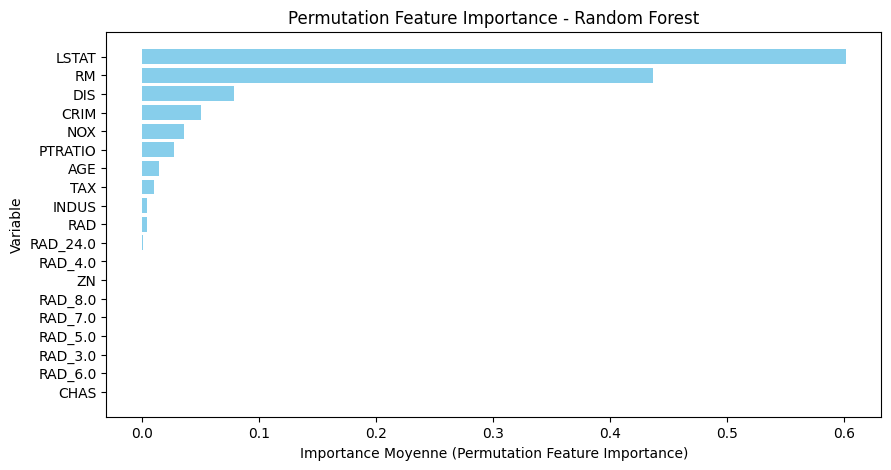

In [171]:

# importance par permutation
pfi_result = permutation_importance(rf_model, X_test_s, y_test, n_repeats=10, random_state=42)

# Organisation des résultats
sorted_idx = np.argsort(pfi_result.importances_mean)[::-1]  # Trier par importance décroissante
pfi_importances = pd.DataFrame({
    "Variable": X_test_s.columns[sorted_idx],
    "Importance Moyenne": pfi_result.importances_mean[sorted_idx]
})

# graphique
plt.figure(figsize=(10, 5))
plt.barh(pfi_importances["Variable"], pfi_importances["Importance Moyenne"], color="skyblue")
plt.xlabel("Importance Moyenne (Permutation Feature Importance)")
plt.ylabel("Variable")
plt.title("Permutation Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()




Le Permutation Feature Importance (PFI) mesure l’impact réel de chaque variable en évaluant la baisse de performance du modèle lorsqu’on perturbe une variable donnée. Plus l’importance est grande, plus la variable est essentielle pour la prédiction.

Le pourcentage de population pauvre c’est la variable la plus importante pour le modele random forest, suivi par le nombre de pièces  et la distance aux centres. La variable DIS semble plus influente en PFI qu’en ALE/PDP, suggérant qu’elle capture une information importante, peut-être en lien avec d’autres variables.

Nous avons aussi des variables modérément importantes comme  CRIM (Taux de criminalité), NOX (Pollution) et  PTRATIO (Ratio élèves/professeurs) et faiblement importants TAX, INDUS, RAD

### 7) Réaliser une explicabilité par individu sur le modèle RF
- 1) ICE, le PDP est-il une bonne représentation des variables importantes de votre modèle?
- 2) LIME
- 3) SHAP watterfall plot

### ICE (Individual Conditional Expectation)

Nous utilisons les courbes ICE (Individual Conditional Expectation), qui affichent les effets des variables pour chaque individu, contrairement au PDP qui montre une moyenne globale.

Le PDP ne montre que la tendance moyenne d’une variable sur MEDV, alors que ICE montre l’impact pour chaque individu et permet d’identifier si l’effet est stable ou si le modèle se comporte différemment selon les individus.

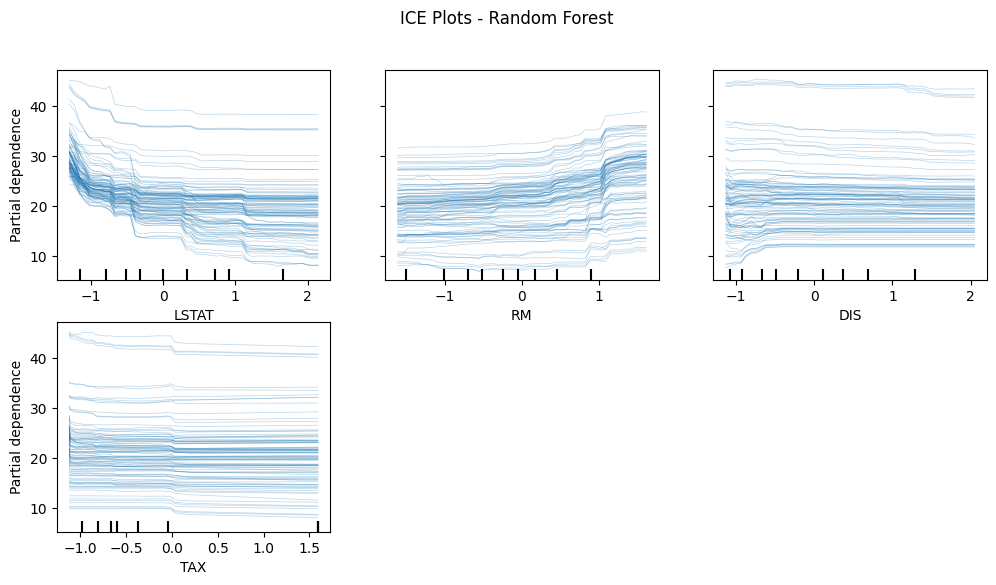

In [172]:


# Sélection des variables clés
features = ["LSTAT", "RM", "DIS", "TAX"]

# Tracé des ICE plots
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(rf_optimized, 
                                        X_test_s, 
                                        features, 
                                        kind="individual",  # ICE curves
                                        grid_resolution=50, 
                                        ax=ax)

plt.suptitle("ICE Plots - Random Forest")
plt.show()


La variable LSTAT, on remarque une forte diminution du prix des maisons lorsque cette variable augmente, ce qui confirme la relation négative déjà observée dans le PDP. Toutefois, les courbes individuelles présentent des variations, indiquant que l'effet n'est pas strictement uniforme pour toutes les observations. De même, pour RM, bien que la tendance générale soit une augmentation du prix avec le nombre de pièces, certaines courbes montrent des écarts, suggérant des interactions avec d'autres facteurs.

Concernant DIS, les ICE plots confirment que cette variable a un impact limité sur MEDV, ce qui était déjà visible dans le PDP. Cependant, quelques courbes individuelles montrent des variations plus marquées, indiquant que l’effet peut être plus significatif pour certains individus. Pour TAX, l’effet observé est moins linéaire : alors que le PDP indiquait un effet modéré, les courbes ICE révèlent des comportements plus variés, avec certains individus fortement affectés par l’augmentation de la taxe, tandis que d’autres le sont beaucoup moins.

Ainsi, le PDP est une bonne représentation globale des tendances générales du modèle, notamment pour LSTAT et RM, où les variations restent relativement homogènes. Cependant, pour des variables comme DIS et TAX, les ICE plots révèlent des effets plus complexes et hétérogènes.

## LIME 

L’objectif de LIME (( Local interpretable model-explanation )  est d’expliquer les prédictions du modèle utilisé, en approximant le modèle complexe par un modèle plus simple (souvent linéaire) autour d’une instance spécifique.

Pour comprendre comment le modèle prend une décision sur une maison en particulier, nous utilisons LIME pour expliquer une prédiction spécifique:

In [173]:
#  observation à expliquer (ex : première observation du jeu de test)
idx = 0
sample_instance = X_test_s.iloc[idx].values.reshape(1, -1)

#  LIME
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_s.values,  
    feature_names=X_train_s.columns.tolist(),  # Assurez-vous que ce sont bien les bonnes features
    class_names=['MEDV'],  # Ajout du nom de la cible
    mode="regression"
)

# Explication de la prédiction pour cette instance
exp = explainer.explain_instance(sample_instance[0], rf_model.predict, num_features=5)

# graphique LIME
exp.show_in_notebook()

c:\Users\isabel\M2_ECAP\semestre_1\SVM_reseaux_neurones\env_SVM_reseaux_n\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


D'apres LIME le  modèle prédit  un prix médian des maisons d'environ 23.46 pour cette observation, les valeurs possibles se trouvent entre 10.52 et 44.76.
Dans LIME, un effet positif signifie que l’augmentation de la variable contribue à augmenter la prédiction et un effet négatif signifie qu’elle la réduit


Les variables ayant un effet négatif (diminution du prix) sont :

-  RM  : Moins de pièces dans la maison réduit fortement le prix
- INDUS : Une forte proportion de terrains industriels est associée à une baisse du prix

Les variables ayant un effet positif (augmentation du prix)

- LSTAT  : Une population plus pauvre dans le quartier tend à diminuer les prix
- PTRATIO : Un ratio élèves/enseignants plus faible est associé à des prix plus élevés
- RAD_6.0  : L’accessibilité à certaines autoroutes semble avoir un effet positi


Cependant, l'effet positif de LSTAT et PTRATIO dans cette prédiction spécifique peut sembler contre-intuitif par rapport à leur tendance générale. En effet, LSTAT est habituellement négativement corrélé avec MEDV, ce qui signifie que dans la plupart des cas, une augmentation de la population à faible revenu entraîne une diminution du prix des maisons. De même, un PTRATIO élevé (un grand nombre d'élèves par enseignant) est généralement associé à une baisse de la qualité de l’éducation et donc à des prix immobiliers plus faibles. Ces résultats locaux suggèrent que l'importance de ces variables dans la prédiction dépend fortement du contexte spécifique de cette observation

### SHAP watterfall plot

SHAP (SHapley Additive exPlanations) est une méthode d’explicabilité locale qui attribue à chaque variable une contribution marginale à la prédiction d’une observation spécifique. Le Waterfall Plot permet de visualiser comment chaque variable ajuste la prédiction finale à partir de la moyenne.

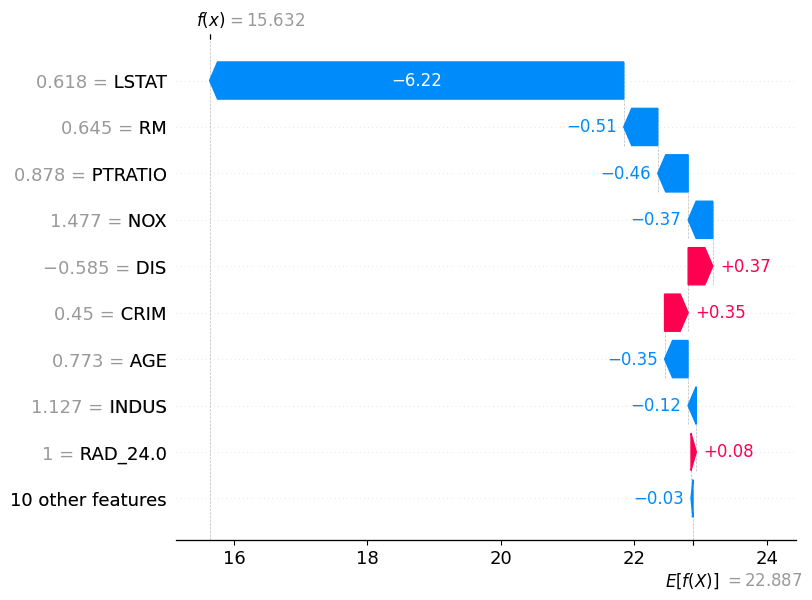

In [174]:

#  le module explainer de Shap,  ce n'est pas le même car c'est un modèle basé sur des abres
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test_s)

shap.initjs()
# visualize the first prediction's explanation
shap.waterfall_plot(shap_values[86])


Ce SHAP Waterfall Plot montre comment le modèle Random Forest prédit le prix médian des maisons pour une observation issue du jeu de test.

E[f(X)]=22.887 → Moyenne des prédictions du modèle sur l'ensemble des données test

f(x)=15.632 → Prédiction finale pour cette observation spécifique

Les variables en bleu ont un effet négatif (elles réduisent la prédiction)

Les variables en rouge ont un effet positif (elles augmentent la prédiction)


 La variable LSTAT a l'impact négatif le plus fort, ce qui signifie qu’un pourcentage élevé de population à faible revenu entraîne une baisse significative du prix estimé. De même, un nombre réduit de pièces dans le logement (RM) et un ratio élèves/professeurs élevé (PTRATIO) contribuent également à une diminution du prix. L’exposition à la pollution (NOX) a un effet négatif plus modéré.

À l’inverse, certaines variables influencent positivement la prédiction. Le taux de criminalité (CRIM), bien que généralement perçu comme un facteur négatif, semble ici légèrement augmenter le prix estimé, ce qui pourrait être dû à des interactions avec d’autres variables. L’accessibilité aux infrastructures routières, notamment via la variable RAD_24.0, joue également un rôle mineur dans la hausse de la prédiction.

Une autre représentation de ce graphique applatie de ce graphique est le force_plot

In [175]:
shap.force_plot(shap_values[86])

### 8) Explorer les graphiques SHAP étudiés  dans la partie CM
   1) beeswarm (Contribution des variables)
   2) scatter (équivalent pdp)

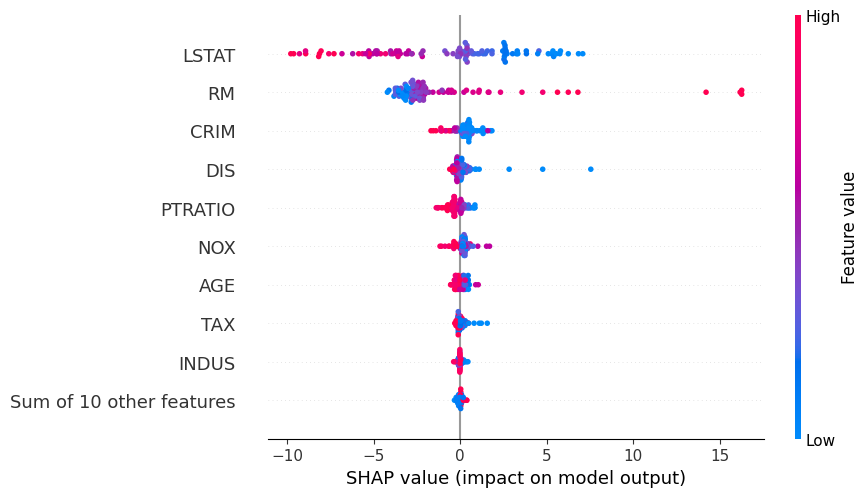

In [176]:
#Graphique beeswarm, interprétabilité globale 
shap.plots.beeswarm(shap_values)

Le SHAP Beeswarm Plot fournit une interprétation globale du modèle en illustrant l'impact des différentes variables sur les prédictions. Chaque point représente une observation du jeu de test, et la position horizontale indique l’effet de cette variable sur la prédiction. Un SHAP value positif signifie que la variable augmente la prédiction du prix de la maison, tandis qu’un SHAP value négatif la diminue.

Les couleurs permettent de visualiser la valeur des variables : en rouge, les valeurs élevées et en bleu, les valeurs faibles. 


La variable LSTAT (pourcentage de population à faible revenu) montre une relation négative avec le prix médian des maisons. Les valeurs élevées de LSTAT (en rouge) sont associées à des valeurs SHAP négatives, ce qui signifie que plus la proportion de population défavorisée est grande, plus l'impact sur le prix est négatif. Inversement, les valeurs faibles de LSTAT (en bleu) ont un effet positif sur le prix des maisons.

La variable RM (nombre moyen de pièces par logement) suit globalement une tendance inverse. On observe que les valeurs SHAP sont positives pour les valeurs élevées de RM (en rouge), indiquant que plus une maison a de pièces, plus cela a un effet positif sur la prédiction du prix. Cependant, l'ambiguïté des couleurs à gauche du 0 pourrait indiquer que l'effet de RM n'est pas parfaitement monotone ou qu'il interagit avec d'autres variables.

La variable CRIM (taux de criminalité) montre un effet plus mitigé : bien que globalement négatif, il y a quelques valeurs rouges du côté droit, suggérant que dans certaines conditions, un taux de criminalité élevé peut ne pas avoir un impact systématiquement négatif sur le prix des maisons.


### Scatter 

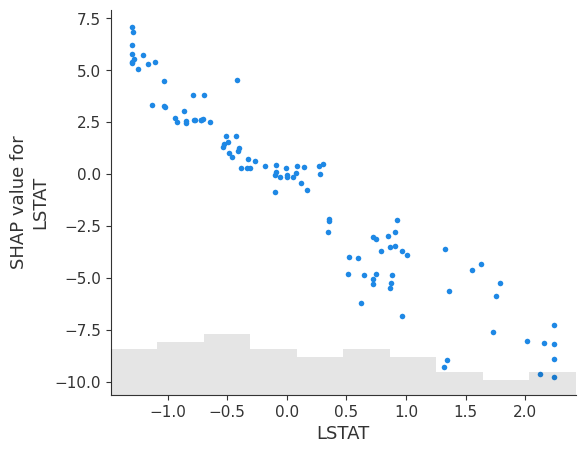

In [177]:
shap.plots.scatter(shap_values[:, 'LSTAT'])

Ce SHAP scatter plot montre la relation entre LSTAT (le pourcentage de population à faible revenu) et son impact sur la prédiction des prix des maisons

- Relation Négative : L’axe des X représente la valeur de LSTAT.

L’axe des Y représente la valeur SHAP, c’est-à-dire l’impact de LSTAT sur la prédiction du prix des maisons (MEDV).

On observe une tendance clairement décroissante, ce qui signifie que plus LSTAT est élevé, plus il réduit la prédiction des prix.

 Explication plus riche avec SHAP et scatter en associant la variable analysée (LSTAT) avec une autre qui pourrait influencer son impact sur la prédiction

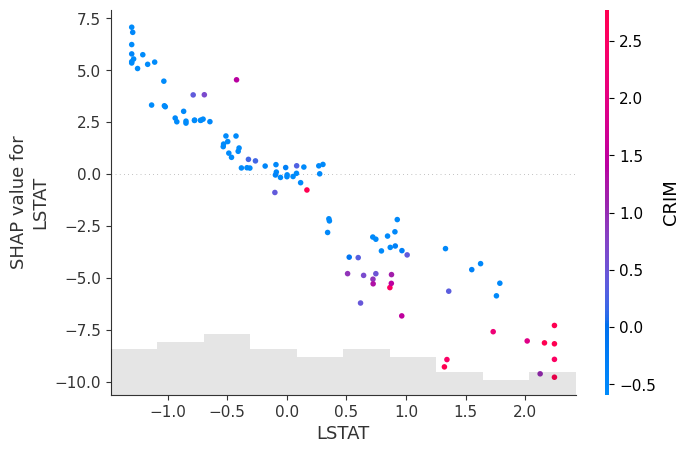

In [178]:
shap.plots.scatter(shap_values[:, 'LSTAT'], color=shap_values ) #SHAP choisit automatiquement une autre variable corrélée à la feature sélectionnée 


Effet de la couleur (CRIM) : Les points sont colorés selon CRIM (le taux de criminalité)


À gauche (LSTAT faible, quartiers plus riches) : Les points sont majoritairement bleus, ce qui signifie que ces quartiers ont un faible taux de criminalité (CRIM bas)

À droite (LSTAT élevé, quartiers plus pauvres) : Les points deviennent progressivement rouges, ce qui indique une augmentation du taux de criminalité (CRIM élevé)

Cela renforce l'idée que les quartiers à forte proportion de population défavorisée sont souvent associés à un taux de criminalité plus élevé, ce qui pourrait expliquer pourquoi les prix des maisons chutent lorsque LSTAT augmente

## Pipeline
#### Interpreter les shapley values après la standardisation 

L'une des difficultés  avec la standardisation est que les valeurs des variables sont converties en une échelle centrée à 0 et réduite à un écart-type de 1, rendant l'interprétation plus complexe dans les analyses SHAP. En effet, un SHAP scatter plot affichant des valeurs standardisées ne permet pas de comprendre directement comment une variation réelle de la variable affecte la prédiction. Pour pallier ce problème, nous remplaçons les données standardisées utilisées par SHAP par leurs valeurs originales a l'aide d'une pipeline. Cette approche permet d'obtenir des SHAP scatter plots interprétables, où l'axe X affiche les vraies valeurs des variables au lieu de leurs versions transformées.

PermutationExplainer explainer: 103it [07:10,  4.31s/it]                         


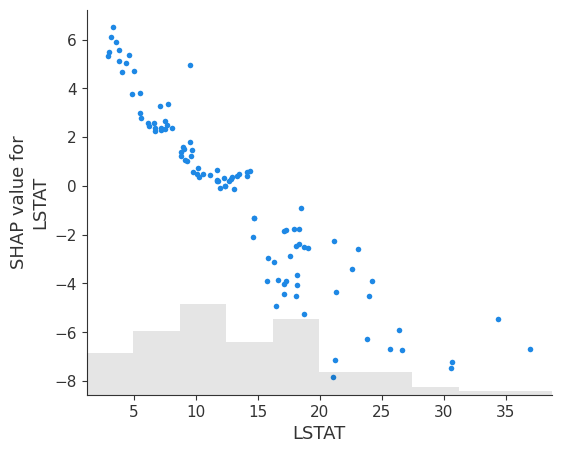

In [ ]:

# Définition des variables
log_vars = ['CRIM', 'ZN', 'DIS', 'LSTAT']  # Variables à transformer en log
num_vars = ['INDUS', 'NOX', 'RM', 'AGE', 'TAX', 'PTRATIO']  # Standardisation seulement
cat_vars = ['RAD']  # Encodage One-Hot
binary_vars = ['CHAS']  # Gardée telle quelle

# Définition des transformations
log_transformer = FunctionTransformer(np.log1p)  # Appliquer log(1+X)

# ColumnTransformer pour pipeline
preprocessor = ColumnTransformer([
    ("log", Pipeline([("log", log_transformer), ("scaler", StandardScaler())]), log_vars),  # Log + standardisation
    ("num", StandardScaler(), num_vars),  # Standardisation des autres variables numériques
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_vars)  # One-Hot Encoding
], remainder="passthrough")  # CHAS est gardée telle quelle

# Séparation des données
X = df.drop(columns=["MEDV"]) 
 # Variables explicatives
y = df["MEDV"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42))
])

# Entraînement du modèle
model.fit(X_train, y_train)


#SHAP 
# SHAP - Explication du modèle sans transformer X_train manuellement
explainer = shap.Explainer(model.predict, X_train)

# SHAP sur X_test 
shap_values = explainer(X_test)
# Remplacement des valeurs transformées par les valeurs originales pour une meilleure interprétation
shap_values.data = X_test.values  

# SHAP scatter plot avec les vraies valeurs
shap.plots.scatter(shap_values[:, 11])  # 11 correspond à LSTAT



Le graphique montre clairement que l’augmentation de LSTAT (pourcentage de ménages à faible revenu) est associée à une diminution des valeurs SHAP, indiquant une baisse du prix prédit des maisons dans ces quartiers. Cette relation négative reflète l’impact de la composition socio-économique du quartier sur la valeur immobilière.

Pour **LSTAT ≈ 5 %**, les valeurs SHAP sont proches de 0 mais possitifs , ce qui signifie que dans ces quartiers, le taux de population défavorisée n’a pas d’effet négatif significatif sur le prix de l’habitation. 

Lorsque **LSTAT atteint environ 15 %**, la plupart des points prennent des valeurs SHAP négatives, indiquant une diminution estimée du prix des maisons à mesure que la proportion de ménages à faible revenu augmente. Cet effet s’accentue avec **LSTAT > 20 %**, où la majorité des points restent négatifs, signifiant une forte dévalorisation des biens immobiliers dans ces quartiers.

Cependant, on observe quelques points isolés entre **LSTAT ≈ 10-15 %** avec des valeurs SHAP qui augmentent , ce qui signifie que dans certaines situations spécifiques, la présence d’une population plus défavorisée ne se traduit pas nécessairement par une baisse des prix. Cela pourrait être dû à des facteurs compensatoires, comme une localisation avantageuse, la proximité d’infrastructures importantes, ou des caractéristiques intrinsèques des logements (ex. nombre de pièces élevé). Ces exceptions suggèrent que l’effet de LSTAT n’est **pas strictement linéaire** et qu’il interagit avec d’autres variables du modèle.

In [185]:
print("Variables après transformation :", X_test.columns.tolist()) # verification que 11 est bien LSTAT


Variables après transformation : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']
